In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
t1_data = pd.read_excel("../multi_omics/T1.xlsx")
t2_data = pd.read_excel("../multi_omics/T2.xlsx")
adc_data = pd.read_excel("../multi_omics/ADC.xlsx")

# Unsupervised Data Preprocessing

In [4]:
# 1. Merge three modalities
merged = t1_data.merge(
    t2_data,
    on=["case", "center"],
    suffixes=("_t1", "_t2")
)

merged = merged.merge(
    adc_data,
    on=["case", "center"]
)

# Rename ADC feature columns, keep ADC label as "Label"
adc_cols = [
    col for col in merged.columns
    if col not in ["case", "center"]
    and not col.endswith("_t1")
    and not col.endswith("_t2")
]

rename_dict = {
    col: f"{col}_adc"
    for col in adc_cols
    if col != "Label"
}
merged = merged.rename(columns=rename_dict)

# Drop rows with any missing value across all modalities
merged = merged.dropna().reset_index(drop=True)

print("After dropping rows with NA across all modalities:", merged.shape)

# 2. Extract labels
t1_label = merged["Label_t1"].values
t2_label = merged["Label_t2"].values
adc_label = merged["Label"].values

assert np.all(t1_label == t2_label), "T1 and T2 labels are inconsistent"
assert np.all(t1_label == adc_label), "T1 and ADC labels are inconsistent"

y = t1_label.copy()

# 3. Extract feature columns
t1_features = [col for col in merged.columns if col.endswith("_t1") and col != "Label_t1"]
t2_features = [col for col in merged.columns if col.endswith("_t2") and col != "Label_t2"]
adc_features = [col for col in merged.columns if col.endswith("_adc")]

# Keep as DataFrames so feature names are preserved
t1_df_raw = merged[t1_features].copy()
t2_df_raw = merged[t2_features].copy()
adc_df_raw = merged[adc_features].copy()

print("Raw aligned shapes:")
print("T1:", t1_df_raw.shape)
print("T2:", t2_df_raw.shape)
print("ADC:", adc_df_raw.shape)

# 4. Standardization
def standardize_df(df):
    scaler = StandardScaler()
    X_std = scaler.fit_transform(df)
    return pd.DataFrame(X_std, columns=df.columns, index=df.index), scaler

t1_std_df, t1_scaler = standardize_df(t1_df_raw)
t2_std_df, t2_scaler = standardize_df(t2_df_raw)
adc_std_df, adc_scaler = standardize_df(adc_df_raw)

# 5. Correlation filtering
def correlation_filter_fit(X_df, threshold=0.8):
    """
    X_df: pandas DataFrame
    Returns:
        X_filtered: filtered DataFrame
        keep_mask: boolean mask
        kept_columns: list of kept feature names
    """
    corr = X_df.corr().abs()
    n = corr.shape[0]
    keep = np.ones(n, dtype=bool)
    cols = X_df.columns.to_list()

    for i in range(n):
        if not keep[i]:
            continue
        for j in range(i + 1, n):
            if keep[j] and corr.iloc[i, j] > threshold:
                keep[j] = False

    kept_columns = X_df.columns[keep]
    X_filtered = X_df.loc[:, kept_columns].copy()

    return X_filtered, keep, kept_columns

def preprocess_filter(X_df, corr_threshold=0.9, verbose=True):
    X_filtered, keep_mask, kept_columns = correlation_filter_fit(X_df, threshold=corr_threshold)

    if verbose:
        print(f"\nOriginal features: {X_df.shape[1]}")
        print(f"After correlation filtering: {X_filtered.shape[1]}")

    return X_filtered, kept_columns

t1_df, t1_kept = preprocess_filter(t1_std_df, corr_threshold=0.8)
t2_df, t2_kept = preprocess_filter(t2_std_df, corr_threshold=0.8)
adc_df, adc_kept = preprocess_filter(adc_std_df, corr_threshold=0.8)

print("\nFinal filtered shapes:")
print("T1:", t1_df.shape)
print("T2:", t2_df.shape)
print("ADC:", adc_df.shape)

After dropping rows with NA across all modalities: (329, 1193)
Raw aligned shapes:
T1: (329, 396)
T2: (329, 396)
ADC: (329, 396)

Original features: 396
After correlation filtering: 387

Original features: 396
After correlation filtering: 396

Original features: 396
After correlation filtering: 396

Final filtered shapes:
T1: (329, 387)
T2: (329, 396)
ADC: (329, 396)


# Simple Spectral Clustering

In [5]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

# Clustering stability checking function
def spectral_stability(X, k, n_runs=100, subsample_frac=0.8, gamma=None, random_state=507):
    n = X.shape[0]
    rng = np.random.RandomState(random_state)

    if gamma is None:
        gamma = 1 / X.shape[1]   

    labels_list = []

    for i in range(n_runs):
        idx = rng.choice(n, size=int(subsample_frac * n), replace=False)
        X_sub = X[idx]

        model = SpectralClustering(
            n_clusters=k,
            affinity='rbf',
            gamma=gamma,
            assign_labels='kmeans',
            random_state=rng.randint(10000)
        )

        labels = model.fit_predict(X_sub)
        labels_list.append((idx, labels))

    # pairwise ARI
    ari_scores = []

    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            idx_i, labels_i = labels_list[i]
            idx_j, labels_j = labels_list[j]

            common = np.intersect1d(idx_i, idx_j)
            if len(common) < 10:
                continue

            map_i = {v: k for k, v in enumerate(idx_i)}
            map_j = {v: k for k, v in enumerate(idx_j)}

            li = [labels_i[map_i[x]] for x in common]
            lj = [labels_j[map_j[x]] for x in common]

            ari_scores.append(adjusted_rand_score(li, lj))

    return np.mean(ari_scores)

# concensus matrix block patterns
def spectral_consensus_matrix(X, k, n_runs=50, subsample_frac=0.8, gamma=None, random_state=507):
    n = X.shape[0]
    rng = np.random.RandomState(random_state)

    if gamma is None:
        gamma = 1 / X.shape[1]

    together = np.zeros((n, n))
    cooccur = np.zeros((n, n))

    for run in range(n_runs):
        idx = rng.choice(n, size=int(subsample_frac * n), replace=False)
        X_sub = X[idx]

        model = SpectralClustering(
            n_clusters=k,
            affinity='rbf',
            gamma=gamma,
            assign_labels='kmeans',
            random_state=rng.randint(10000)
        )

        labels = model.fit_predict(X_sub)

        for a in range(len(idx)):
            i = idx[a]
            for b in range(len(idx)):
                j = idx[b]
                cooccur[i, j] += 1
                if labels[a] == labels[b]:
                    together[i, j] += 1

    consensus = np.divide(
        together,
        cooccur,
        out=np.zeros_like(together),
        where=cooccur > 0
    )

    return consensus

def pac_score(consensus, lower=0.1, upper=0.9):
    n = consensus.shape[0]
    upper_tri = consensus[np.triu_indices(n, k=1)]
    return np.mean((upper_tri > lower) & (upper_tri < upper))

def plot_consensus_matrix_with_blocks(consensus, labels, title="Consensus Matrix"):
    labels = np.asarray(labels)
    order = np.argsort(labels)

    C_ord = consensus[order][:, order]
    labels_ord = labels[order]

    plt.figure(figsize=(7, 6))
    im = plt.imshow(C_ord, aspect='auto')
    plt.colorbar(im, label="Consensus")

    # draw boundaries between clusters
    change_points = np.where(np.diff(labels_ord) != 0)[0] + 1
    for cp in change_points:
        plt.axhline(cp - 0.5, linewidth=1.5)
        plt.axvline(cp - 0.5, linewidth=1.5)

    plt.title(title)
    plt.xlabel("Samples (ordered by cluster)")
    plt.ylabel("Samples (ordered by cluster)")
    plt.tight_layout()
    plt.show()

In [6]:
# Dimensionality reduction for visualization
from sklearn.manifold import TSNE, Isomap

def get_2d_embedding(X, method="tsne", random_state=507):
    if method == "tsne":
        model = TSNE(
            n_components=2,
            perplexity=30,
            init="pca",
            random_state=random_state
        )
        X_2d = model.fit_transform(X)

    elif method == "isomap":
        model = Isomap(
            n_components=2,
            n_neighbors=10
        )
        X_2d = model.fit_transform(X)

    else:
        raise ValueError("method must be 'tsne' or 'isomap'")

    return X_2d


K = 2


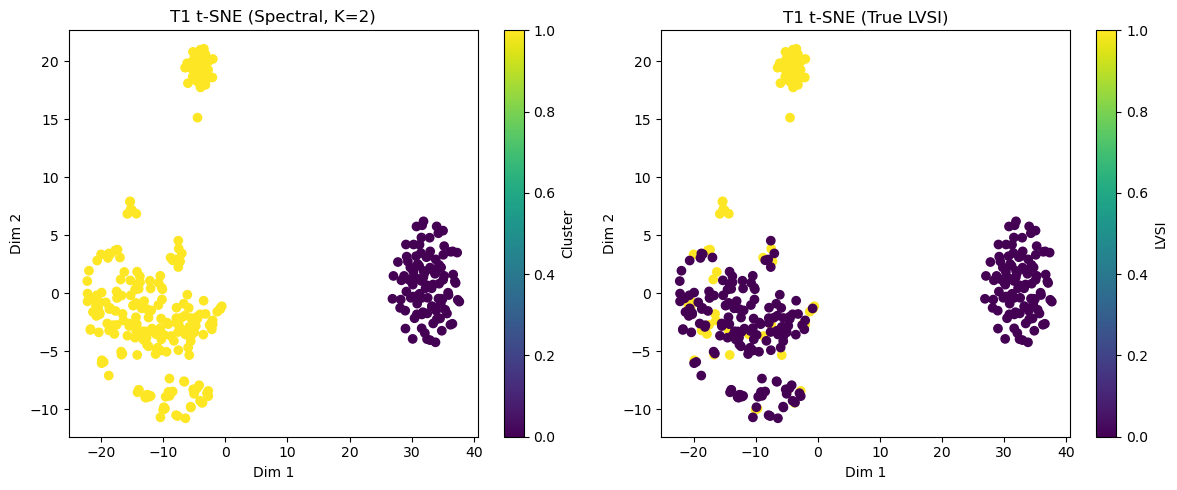

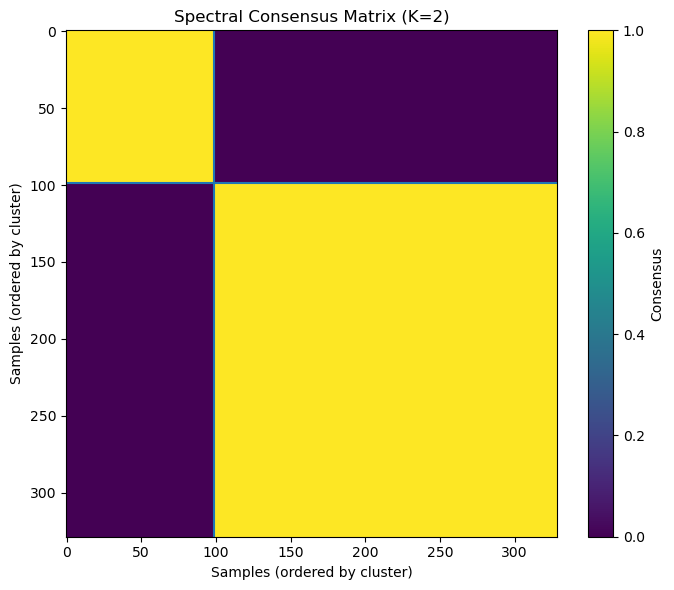

Stability (ARI): 1.0000
PAC: 0.0000

K = 3


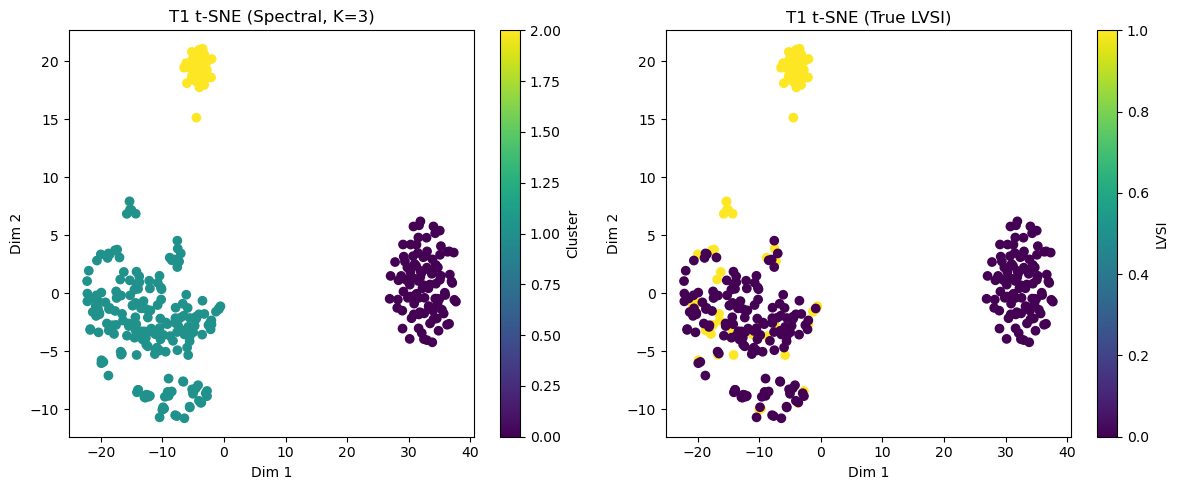

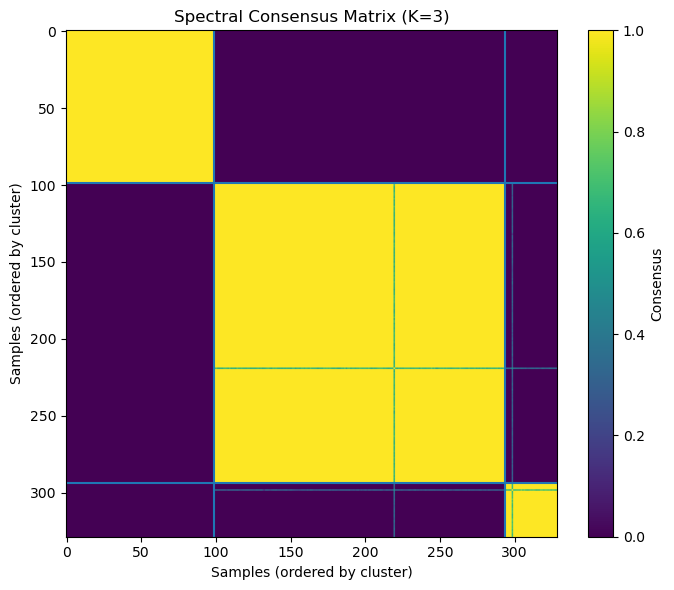

Stability (ARI): 0.9934
PAC: 0.0085

K = 4


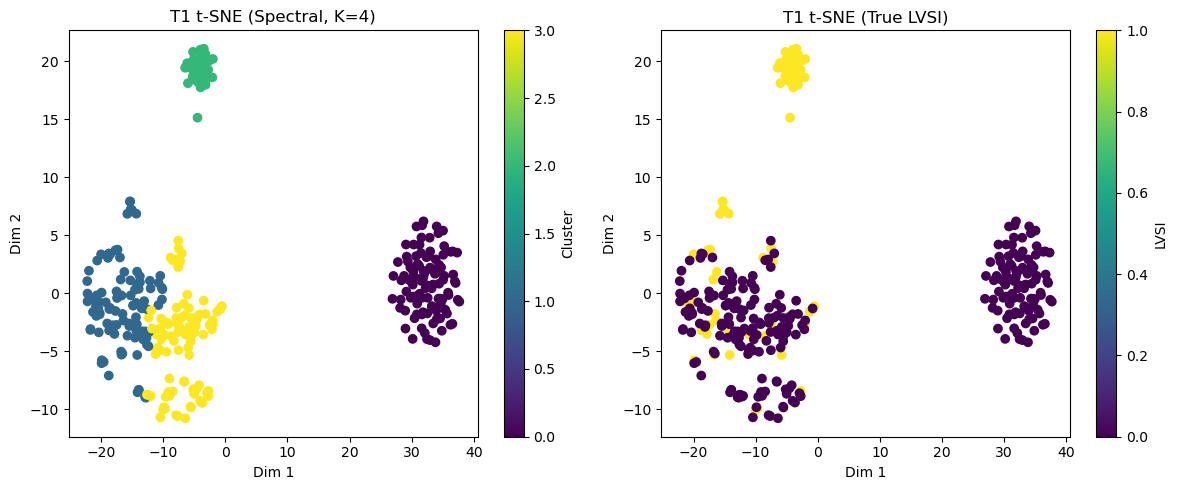

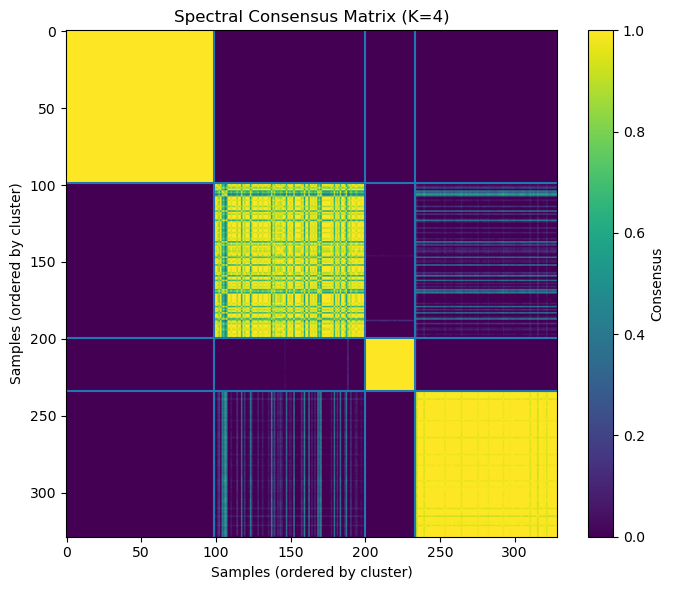

Stability (ARI): 0.8967
PAC: 0.0860

K = 5


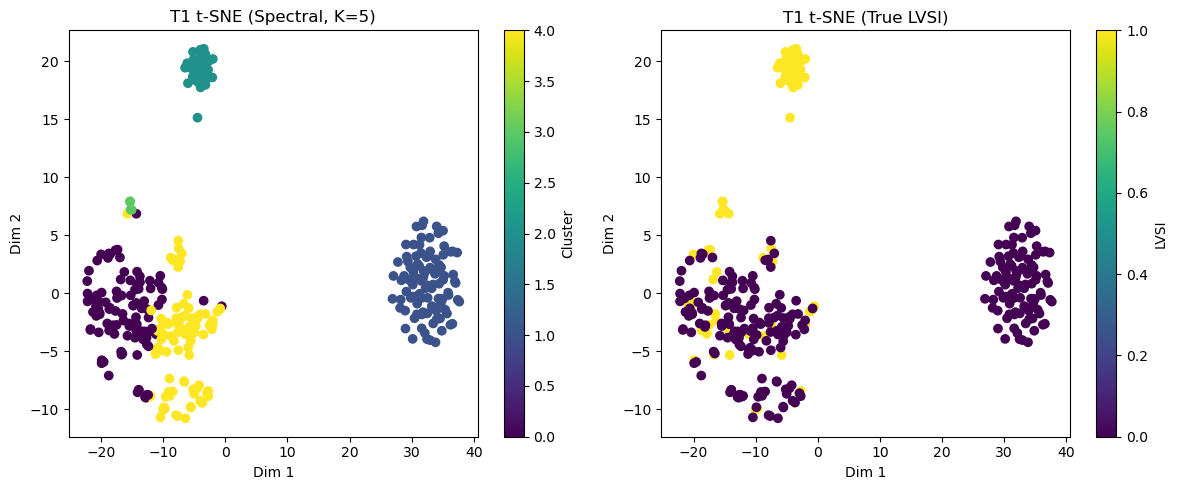

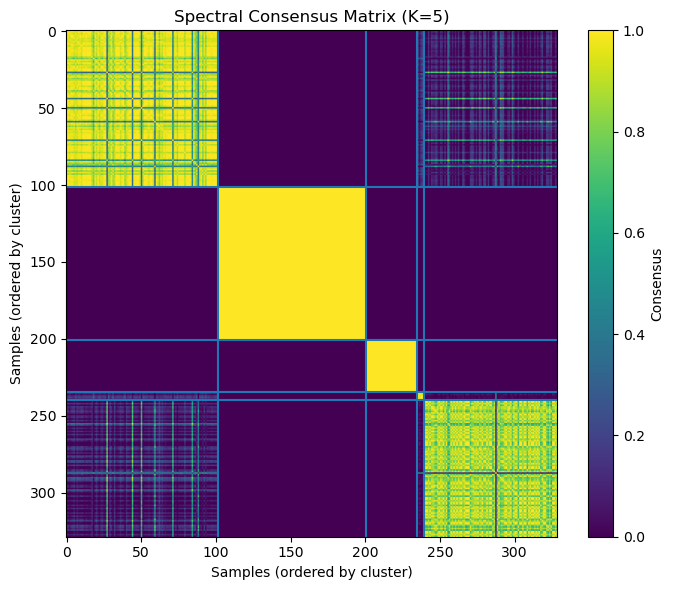

Stability (ARI): 0.8448
PAC: 0.1581


In [7]:
X = t1_df.values
X_2d_tsne = get_2d_embedding(X, method="tsne", random_state=507)

K_range = [2, 3, 4, 5]

stability_scores = []
pac_scores = []

for k in K_range:
    print(f"\nK = {k}")

    spectral = SpectralClustering(
        n_clusters=k,
        affinity="rbf",
        gamma=1 / X.shape[1],
        assign_labels="kmeans",
        random_state=507
    )
    clusters = spectral.fit_predict(X)


    plt.figure(figsize=(12, 5))

    # Left: cluster visualization
    plt.subplot(1, 2, 1)
    scatter1 = plt.scatter(X_2d_tsne[:, 0], X_2d_tsne[:, 1], c=clusters)
    plt.title(f"T1 t-SNE (Spectral, K={k})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.colorbar(scatter1, label="Cluster")

    # Right: true labels
    plt.subplot(1, 2, 2)
    scatter2 = plt.scatter(X_2d_tsne[:, 0], X_2d_tsne[:, 1], c=y)
    plt.title("T1 t-SNE (True LVSI)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.colorbar(scatter2, label="LVSI")
    plt.tight_layout()
    plt.show()

    stab = spectral_stability(X, k, n_runs=100)
    stability_scores.append(stab)

    consensus = spectral_consensus_matrix(X, k, n_runs=100)
    pac = pac_score(consensus)
    pac_scores.append(pac)

    plot_consensus_matrix_with_blocks(consensus, clusters, title=f"Spectral Consensus Matrix (K={k})")

    print(f"Stability (ARI): {stab:.4f}")
    print(f"PAC: {pac:.4f}")

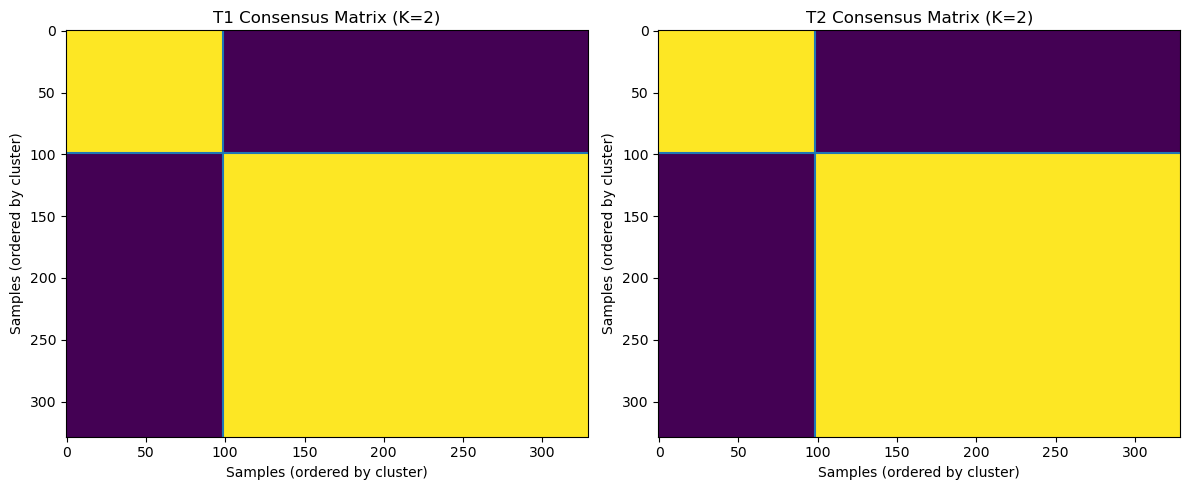

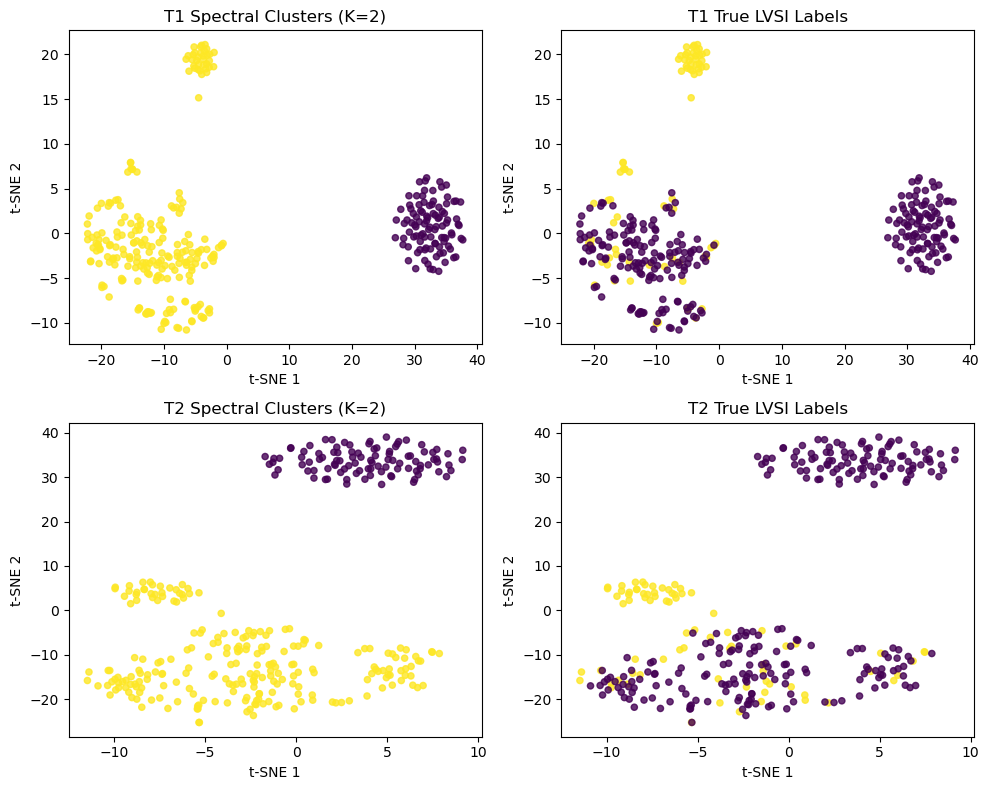

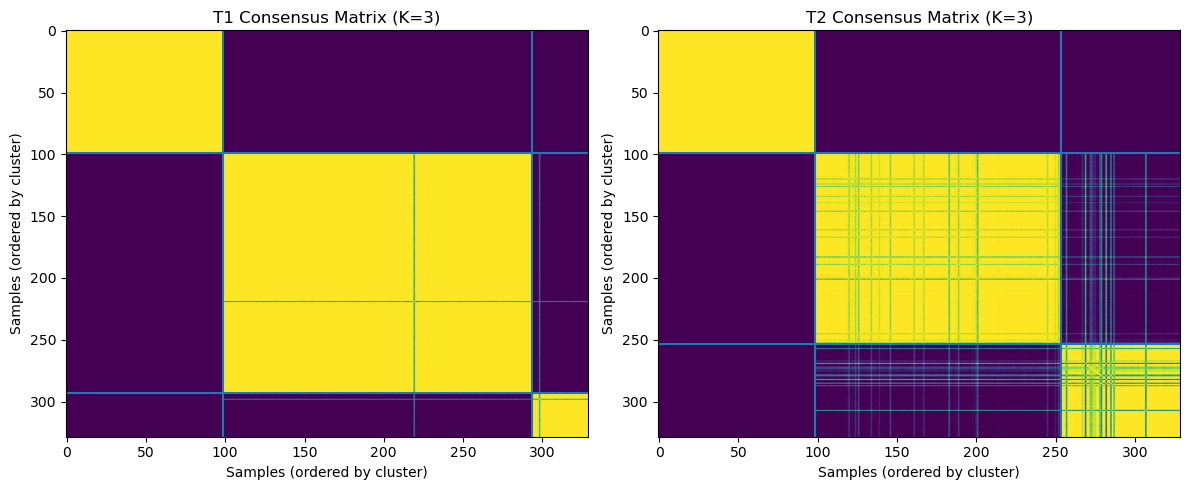

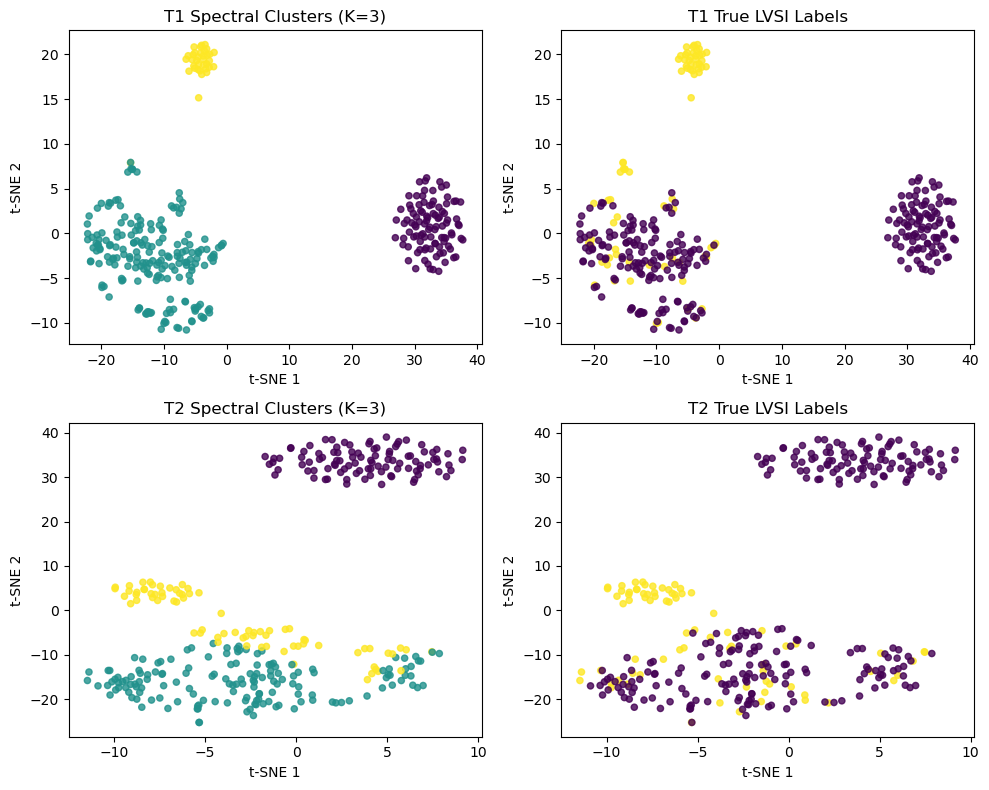

In [14]:
# For better visualization

X_t1 = t1_df.values
X_t2 = t2_df.values
y_true = np.asarray(y).ravel()

X_t1_2d = get_2d_embedding(X_t1, method="tsne", random_state=507)
X_t2_2d = get_2d_embedding(X_t2, method="tsne", random_state=507)


for k in [2, 3]:
    clusters_t1 = SpectralClustering(
        n_clusters=k,
        affinity="rbf",
        gamma=1 / X_t1.shape[1],
        assign_labels="kmeans",
        random_state=507
    ).fit_predict(X_t1)

    clusters_t2 = SpectralClustering(
        n_clusters=k,
        affinity="rbf",
        gamma=1 / X_t2.shape[1],
        assign_labels="kmeans",
        random_state=507
    ).fit_predict(X_t2)

    consensus_t1 = spectral_consensus_matrix(
        X_t1, k, n_runs=100, subsample_frac=0.8,
        gamma=1 / X_t1.shape[1], random_state=507
    )

    consensus_t2 = spectral_consensus_matrix(
        X_t2, k, n_runs=100, subsample_frac=0.8,
        gamma=1 / X_t2.shape[1], random_state=507
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, consensus, labels, title in zip(
        axes,
        [consensus_t1, consensus_t2],
        [clusters_t1, clusters_t2],
        [f"T1 Consensus Matrix (K={k})", f"T2 Consensus Matrix (K={k})"]
    ):
        order = np.argsort(labels)
        C_ord = consensus[order][:, order]
        labels_ord = labels[order]

        ax.imshow(C_ord, aspect="auto", vmin=0, vmax=1)

        change_points = np.where(np.diff(labels_ord) != 0)[0] + 1
        for cp in change_points:
            ax.axhline(cp - 0.5, linewidth=1.5)
            ax.axvline(cp - 0.5, linewidth=1.5)

        ax.set_title(title)
        ax.set_xlabel("Samples (ordered by cluster)")
        ax.set_ylabel("Samples (ordered by cluster)")

    plt.tight_layout()
    plt.show()


    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # T1 clusters
    axes[0, 0].scatter(X_t1_2d[:, 0], X_t1_2d[:, 1], c=clusters_t1, s=20, alpha=0.8)
    axes[0, 0].set_title(f"T1 Spectral Clusters (K={k})")
    axes[0, 0].set_xlabel("t-SNE 1")
    axes[0, 0].set_ylabel("t-SNE 2")

    # T1 true labels
    axes[0, 1].scatter(X_t1_2d[:, 0], X_t1_2d[:, 1], c=y_true, s=20, alpha=0.8)
    axes[0, 1].set_title("T1 True LVSI Labels")
    axes[0, 1].set_xlabel("t-SNE 1")
    axes[0, 1].set_ylabel("t-SNE 2")
    # T2 clusters
    axes[1, 0].scatter(X_t2_2d[:, 0], X_t2_2d[:, 1], c=clusters_t2, s=20, alpha=0.8)
    axes[1, 0].set_title(f"T2 Spectral Clusters (K={k})")
    axes[1, 0].set_xlabel("t-SNE 1")
    axes[1, 0].set_ylabel("t-SNE 2")
    # T2 true labels
    axes[1, 1].scatter(X_t2_2d[:, 0], X_t2_2d[:, 1], c=y_true, s=20, alpha=0.8)
    axes[1, 1].set_title("T2 True LVSI Labels")
    axes[1, 1].set_xlabel("t-SNE 1")
    axes[1, 1].set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

# K=3 Comparison Analysis

In [9]:
# mixture of label0 and label1
spectral = SpectralClustering(
        n_clusters=3,
        affinity="rbf",
        gamma=1 / X.shape[1],
        assign_labels="kmeans",
        random_state=507
    )
clusters = spectral.fit_predict(X)

df_eval = pd.DataFrame({
    "cluster": clusters,
    "LVSI": y
})

count_table = pd.crosstab(df_eval["cluster"], df_eval["LVSI"])
print("Counts:")
print(count_table)

prop_table = pd.crosstab(
    df_eval["cluster"],
    df_eval["LVSI"],
    normalize="index"
)
print("\nProportions within each cluster:")
print(prop_table)

Counts:
LVSI       0   1
cluster         
0         99   0
1        153  42
2          0  35

Proportions within each cluster:
LVSI            0         1
cluster                    
0        1.000000  0.000000
1        0.784615  0.215385
2        0.000000  1.000000


# Mixture Cluster Supervised Check

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif
def univariate_selection_fit(X_train, y_train, k=50):
    k = min(k, X_train.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_new = selector.fit_transform(X_train, y_train)
    return pd.DataFrame(X_train_new)

ym = y[clusters == 1]

X_t1 = univariate_selection_fit(t1_df.iloc[clusters == 1, :], ym)
X_t2 = univariate_selection_fit(t2_df.iloc[clusters == 1, :], ym)
X_adc = univariate_selection_fit(adc_df.iloc[clusters == 1, :], ym)


feature_sets_train = {
    "T1": (X_t1, ym),
    "T2": (X_t2, ym),
    "ADC": (X_adc, ym),
    "T1+T2": (pd.concat([X_t1, X_t2], axis=1), ym),
    "T1+ADC": (pd.concat([X_t1, X_adc], axis=1), ym),
    "T2+ADC": (pd.concat([X_t2, X_adc], axis=1), ym),
    "T1+T2+ADC": (pd.concat([X_t1, X_t2, X_adc], axis=1), ym),
}

In [11]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

def classification_error(y_true, y_pred):
    return 1.0 - accuracy_score(y_true, y_pred)


def make_model(method, C, penalty="l2"):
    if method == "logistic":
        return LogisticRegression(
            penalty=penalty,
            C=C,
            solver="liblinear",
            max_iter=1000
        )
    elif method == "linear_svm":
        return LinearSVC(
            C=C,
            max_iter=20000
        )
    else:
        raise ValueError("method must be 'logistic' or 'linear_svm'")


def get_model_score(model, X, method):
    if method == "logistic":
        return model.predict_proba(X)[:, 1]
    elif method == "linear_svm":
        return model.decision_function(X)
    else:
        raise ValueError("method must be 'logistic' or 'linear_svm'")
    
def cv_tune_model(X, y, C_grid, method, penalty="l2", n_splits=5, random_state=507):
    X = np.asarray(X)
    y = np.asarray(y)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    best_score = -np.inf
    best_C = None

    for C in C_grid:
        fold_aucs = []

        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            model = make_model(method, C, penalty=penalty)
            model.fit(X_tr, y_tr)

            val_score = get_model_score(model, X_val, method)
            auc = roc_auc_score(y_val, val_score)
            fold_aucs.append(auc)

        mean_auc = np.mean(fold_aucs)

        if mean_auc > best_score:
            best_score = mean_auc
            best_C = C

    return best_C, best_score

def evaluate_model_train_only(X, y, C, method, penalty="l2"):
    X = np.asarray(X)
    y = np.asarray(y)

    model = make_model(method, C, penalty=penalty)
    model.fit(X, y)

    # predictions
    y_pred = model.predict(X)
    y_score = get_model_score(model, X, method)

    # metrics
    train_err = classification_error(y, y_pred)
    train_auc = roc_auc_score(y, y_score)

    train_cm = confusion_matrix(y, y_pred)
    train_report = classification_report(y, y_pred)

    return (
        model,
        train_err,
        train_auc,
        train_cm,
        train_report
    )


In [12]:
C_grid = [0.01, 0.1, 1, 10, 100]

linear_results = []
late_fusion_prepared = {"T1": [None, None], "T2": [None, None], "ADC": [None, None]}

method_name_map = {
    "logistic": "Linear Logistic Regression",
    "linear_svm": "Linear SVM"
}

late_fusion_idx_map = {
    "logistic": 0,
    "linear_svm": 1
}

for name in feature_sets_train:
    print(f"\n===== {name} =====")

    Xtr = np.array(feature_sets_train[name][0])
    ytr = np.array(feature_sets_train[name][1])

    for method in ["logistic", "linear_svm"]:
        best_C, cv_auc = cv_tune_model(
            Xtr, ytr, C_grid,
            method=method,
            penalty="l2"
        )

        (
            model,
            train_err,
            train_auc,
            train_cm,
            train_report
        ) = evaluate_model_train_only(
            Xtr, ytr,
            C=best_C,
            method=method,
            penalty="l2"
        )

        linear_results.append({
            "Feature_Set": name,
            "Model": method_name_map[method],
            "Best_C": best_C,
            "CV_AUC": cv_auc,
            "Train_AUC": train_auc,
            "Train_Error": train_err
        })

        print(f"{method_name_map[method]}: best C = {best_C}")
        print(f"  CV AUC      = {cv_auc:.6f}")
        print(f"  Train AUC   = {train_auc:.6f}")
        print(f"  Train Error = {train_err:.6f}")
        print(f"  Train CM:\n{train_cm}")
        print(f"  Train Report:\n{train_report}")

        # store single-modality fitted models for late fusion
        if name in ["T1", "T2", "ADC"]:
            late_fusion_prepared[name][late_fusion_idx_map[method]] = model

# convert stored lists back to tuples
late_fusion_prepared = {k: tuple(v) for k, v in late_fusion_prepared.items()}

linear_results_df = pd.DataFrame(linear_results)

linear_summary = linear_results_df[
    ["Feature_Set", "Model", "Best_C", "CV_AUC", "Train_AUC", "Train_Error"]
]

linear_summary


===== T1 =====
Linear Logistic Regression: best C = 0.1
  CV AUC      = 0.674211
  Train AUC   = 0.693277
  Train Error = 0.174359
  Train CM:
[[152   1]
 [ 33   9]]
  Train Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90       153
           1       0.90      0.21      0.35        42

    accuracy                           0.83       195
   macro avg       0.86      0.60      0.62       195
weighted avg       0.84      0.83      0.78       195

Linear SVM: best C = 100
  CV AUC      = 0.680908
  Train AUC   = 0.812014
  Train Error = 0.158974
  Train CM:
[[150   3]
 [ 28  14]]
  Train Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91       153
           1       0.82      0.33      0.47        42

    accuracy                           0.84       195
   macro avg       0.83      0.66      0.69       195
weighted avg       0.84      0.84      0.81       195


===== T2 ==

,Feature_Set,Model,Best_C,CV_AUC,Train_AUC,Train_Error
0,T1,Linear Logistic Regression,0.10,0.674211,0.693277,0.174359
1,T1,Linear SVM,100.00,0.680908,0.812014,0.158974
2,T2,Linear Logistic Regression,0.01,0.580060,0.619670,0.210256
3,T2,Linear SVM,1.00,0.573572,0.784158,0.174359
4,ADC,Linear Logistic Regression,0.01,0.646338,0.675848,0.215385
5,ADC,Linear SVM,0.01,0.622145,0.704171,0.194872
6,T1+T2,Linear Logistic Regression,0.01,0.726583,0.771553,0.158974
7,T1+T2,Linear SVM,0.01,0.703327,0.803455,0.153846
8,T1+ADC,Linear Logistic Regression,0.01,0.704050,0.753657,0.169231
9,T1+ADC,Linear SVM,0.01,0.702109,0.798475,0.158974
